# Module 1 — Tracking Data Fundamentals (SkillCorner)  
**Goal:** Load multi-match tracking, normalise orientation (left→right), resample to a common Hz, and smooth noise.  
By the end you'll have a clean per-frame, per-player table you can use for shape features and clustering.


## 0. Setup & Configuration
Update the paths below to your local folders. This notebook assumes:
- `matches.parquet` lists available matches (`id`, `home_team`, `away_team`, ...)
- A `tracking/` folder with one JSON per match: `<match_id>.json`

> Tip: Keep raw data read-only and write any processed files to a separate folder.


In [1]:
#Install packages

#Basic imports
from pathlib import Path
import json
import numpy as np
import pandas as pd

#Stats
import seaborn as sns
from sklearn.cluster import KMeans

#Plotting
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.spatial import ConvexHull, Voronoi

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

#Data directory
from settings import DATA_DIR

In [2]:
# --- Paths (EDIT ME) ---
DATA_DIR = Path(DATA_DIR)
BASE_DIR = DATA_DIR / 'RealMadrid'
MATCHES_PATH = BASE_DIR / 'matches.parquet'
TRACKING_DIR = BASE_DIR / 'tracking'
TRACKING_DIR_PARQUET = BASE_DIR / 'tracking_parquet'

# Output
PROCESSED_DIR = BASE_DIR / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True, parents=True)

# Pitch config (meters)
PITCH_LENGTH = 105.0
PITCH_WIDTH  = 68.0

# Target frequency (Hz)
TARGET_HZ = 10.0
DEFAULT_FPS = 10.0


## 1. Load Matches List
We start by reading the matches table and selecting the subset we want to process.


In [3]:
df_matches = pd.read_parquet(MATCHES_PATH)
df_matches = df_matches.sort_values('date_time').reset_index(drop=True)
df_matches.head()


,id,date_time,home_team,away_team,status,competition_id,season_id,competition_edition_id
0,1021404,2023-08-12T19:30:00Z,"{'id': 273, 'short_name': 'Athletic Bilbao'}","{'id': 262, 'short_name': 'Real Madrid'}",closed,4,28,546
1,1036527,2023-08-19T17:30:00Z,"{'id': 274, 'short_name': 'UD Almería'}","{'id': 262, 'short_name': 'Real Madrid'}",closed,4,28,546
2,1048195,2023-08-25T19:30:00Z,"{'id': 285, 'short_name': 'Celta Vigo'}","{'id': 262, 'short_name': 'Real Madrid'}",closed,4,28,546
3,1064327,2023-09-02T14:15:00Z,"{'id': 262, 'short_name': 'Real Madrid'}","{'id': 268, 'short_name': 'Getafe CF'}",closed,4,28,546
4,1096879,2023-09-17T19:00:00Z,"{'id': 262, 'short_name': 'Real Madrid'}","{'id': 282, 'short_name': 'Real Sociedad'}",closed,4,28,546


## 2. Tracking Reader (per match)
Each tracking JSON is a list of frames.


In [4]:
#Example tracking files
example_match_id = df_matches.loc[0, 'id']
with open(TRACKING_DIR / f"{example_match_id}.json", "r") as f:
    example_tracking_data = json.load(f)

example_tracking_data[1000:1001]  # show frames 1000

[{'frame': 1000,
  'timestamp': '00:01:39.00',
  'period': 1,
  'ball_data': {'x': 13.82, 'y': 29.81, 'z': 0.1, 'is_detected': True},
  'possession': {'player_id': None, 'group': 'home team'},
  'image_corners_projection': {'x_top_left': -13.04,
   'y_top_left': 39.0,
   'x_bottom_left': -6.28,
   'y_bottom_left': -17.74,
   'x_bottom_right': 13.64,
   'y_bottom_right': -19.58,
   'x_top_right': 30.69,
   'y_top_right': 39.0},
  'player_data': [{'x': -37.46,
    'y': 4.46,
    'player_id': 13899,
    'is_detected': False},
   {'x': -11.41, 'y': 6.87, 'player_id': 13903, 'is_detected': False},
   {'x': -7.4, 'y': 18.71, 'player_id': 32276, 'is_detected': True},
   {'x': -10.33, 'y': -9.18, 'player_id': 8259, 'is_detected': False},
   {'x': -6.74, 'y': 26.39, 'player_id': 4463, 'is_detected': True},
   {'x': 3.97, 'y': 23.97, 'player_id': 11692, 'is_detected': True},
   {'x': -4.38, 'y': 6.15, 'player_id': 25739, 'is_detected': True},
   {'x': 10.63, 'y': 20.23, 'player_id': 533061, 'is_

In the script convert_tracking_to_parquet.py we flatten the tracking data into tidy tables with one row per `(frame, player_id)` plus ball rows.

Run that script for at least one match to continue.

In [4]:
all_dfs = []
for match_id in df_matches['id'].values:
    fpath = TRACKING_DIR_PARQUET / f"{match_id}.parquet"
    if fpath.exists():
        print(f"Reading {fpath}")
        temp_tracks = pd.read_parquet(fpath)
        all_dfs.append(temp_tracks)
        
tracking = pd.concat(all_dfs, ignore_index=True)

Reading C:\Users\gusti\Data\SkillCorner\raw\RealMadrid\tracking_parquet\2014987.parquet
Reading C:\Users\gusti\Data\SkillCorner\raw\RealMadrid\tracking_parquet\2016604.parquet
Reading C:\Users\gusti\Data\SkillCorner\raw\RealMadrid\tracking_parquet\2017232.parquet
Reading C:\Users\gusti\Data\SkillCorner\raw\RealMadrid\tracking_parquet\2017683.parquet
Reading C:\Users\gusti\Data\SkillCorner\raw\RealMadrid\tracking_parquet\2018396.parquet


In [5]:
tracking.shape

(4792887, 9)

# 4. Data Quality: 

Checking number of missing players or ball in each frame through the whole dataset:

In [6]:
# Check completeness of each frame: 22 players + 1 ball
frame_check = (
    tracking.groupby(["match_id", "frame"])
    .agg(
        n_players=("player_id", lambda x: x[~(x == -1)].nunique()),  # unique non-ball players
        n_balls=("is_ball", "sum")                                   # count ball rows
    )
    .reset_index()
)

# Identify problematic frames
problems = frame_check[(frame_check["n_players"] < 22) | (frame_check["n_balls"] < 1)]

print(f"Total frames: {len(frame_check)}")
print(f"Frames with issues: {len(problems)}")

# Show a few examples
print(problems.head(10))


Total frames: 210516
Frames with issues: 32579
        match_id  frame  n_players  n_balls
134406   2017683   8720         21        1
134407   2017683   8721         21        1
134408   2017683   8722         21        1
134409   2017683   8723         21        1
134410   2017683   8724         21        1
134411   2017683   8725         21        1
134412   2017683   8726         21        1
134413   2017683   8727         21        1
134414   2017683   8728         21        1
134415   2017683   8729         21        1


In [7]:
# --- Quality check: are all players and the ball detected per frame? ---

# Count entities per frame
frame_counts = (
    tracking
    .groupby(["match_id", "frame"])
    .agg(
        n_players=("is_ball", lambda x: (~x).sum()),   # rows where is_ball=False
        n_balls=("is_ball", "sum")                     # rows where is_ball=True
    )
    .reset_index()
)

# Expected: 22 players and 1 ball per frame
frame_counts["missing_players"] = 22 - frame_counts["n_players"]
frame_counts["missing_ball"] = 1 - frame_counts["n_balls"]

# Frames with issues
issues = frame_counts[(frame_counts["missing_players"] > 0) | (frame_counts["missing_ball"] > 0)]

print(f"Total frames: {len(frame_counts)}")
print(f"Frames with missing detections: {len(issues)}")

# Show a few problematic frames
issues.head(10)


Total frames: 210516
Frames with missing detections: 32579


,match_id,frame,n_players,n_balls,missing_players,missing_ball
134406,2017683,8720,21,1,1,0
134407,2017683,8721,21,1,1,0
134408,2017683,8722,21,1,1,0
134409,2017683,8723,21,1,1,0
134410,2017683,8724,21,1,1,0
134411,2017683,8725,21,1,1,0
134412,2017683,8726,21,1,1,0
134413,2017683,8727,21,1,1,0
134414,2017683,8728,21,1,1,0
134415,2017683,8729,21,1,1,0


In [25]:
issues.missing_ball.mean()

0.0

In [26]:
issues.missing_players.mean()

1.5034531446637405

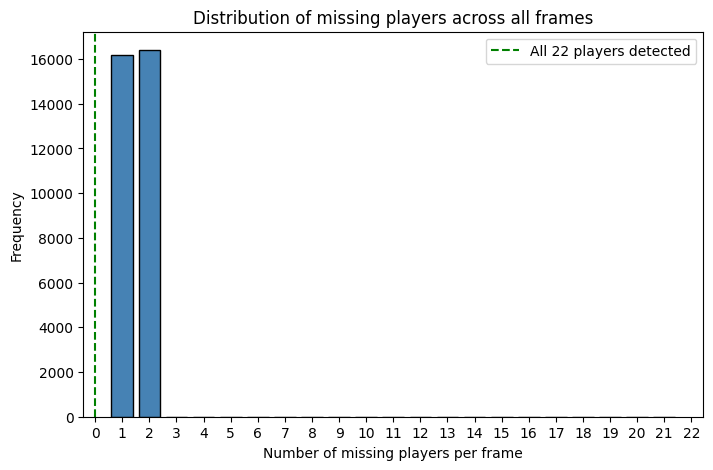

In [27]:
# Compute missing players per frame
frame_check["missing_players"] = 22 - frame_check["n_players"]

# Histogram of missing players
plt.figure(figsize=(8,5))
plt.hist(frame_check["missing_players"], 
         bins=range(1, 23),  # 0 to 22
         align="left", 
         rwidth=0.8, 
         color="steelblue", 
         edgecolor="black")

plt.xlabel("Number of missing players per frame")
plt.ylabel("Frequency")
plt.title("Distribution of missing players across all frames")
plt.xticks(range(0, 23))
plt.axvline(0, color="green", linestyle="--", label="All 22 players detected")
plt.legend()
plt.show()


# 5. Inspect Coordinate Range

in tracking data, figuring out the pitch coordinates and attack direction is crucial before doing anything like clustering, pitch control, or EPV. Let’s break it down into efficient checks you can run:

In [28]:
# X is from (-52,52), y is from (-34,34) with center being (0,0)
print("X range:", tracking["x"].min(), "to", tracking["x"].max())
print("Y range:", tracking["y"].min(), "to", tracking["y"].max())


X range: -65.06 to 58.25
Y range: -41.64 to 38.88


## 6. Inferring Attack Direction

In football analysis, it is very common to normalize the **attack direction**:  
- Team A always attacks **left → right**  
- Team B always attacks **right → left**

Why normalize?  
- ⚖️ Ensures consistency across matches and halves  
- 📊 Makes aggregate statistics interpretable  
- 🎥 Helps coaches quickly understand visuals  

### Step 1: Identify kickoff frames
- At the start of **1st half** (`period=1`, `time=00:00:00.00`)  
- At the start of **2nd half** (`period=2`, `time=00:45:00.00`)  

### Step 2: Compute average X position of Team A
- If Team A’s avg X < midfield → Team A is on the left → attacking right  
- Otherwise → Team A is on the right → attacking left  

### Step 3: Store this as a new column
We’ll add a column `"attack_direction"` in the full dataset:  
- `"R"` = attacking right  
- `"L"` = attacking left


In [8]:
# Example for one match
match_id = tracking["match_id"].iloc[1]
match_data = tracking[tracking["match_id"] == match_id]

# kickoff frame 1st half
kickoff1 = match_data[(match_data["period"] == 1) & 
                      (match_data["time"] == "00:00:00.00")]

# Step 1: freeze team rosters at kickoff1
players = kickoff1[~kickoff1["is_ball"]]
median_x = players["x"].median()
team_a_ids = players[players["x"] <= median_x]["player_id"].unique()
team_b_ids = players[players["x"] >  median_x]["player_id"].unique()

def assign_fixed_teams(df, team_a_ids, team_b_ids):
    df = df.copy()
    def label(pid, is_ball):
        if is_ball:
            return "Ball"
        elif pid in team_a_ids:
            return "Team A"
        elif pid in team_b_ids:
            return "Team B"
        else:
            return "Unknown"
    df["team"] = df.apply(lambda r: label(r["player_id"], r["is_ball"]), axis=1)
    return df

# Assign for kickoff frame
kickoff1 = assign_fixed_teams(kickoff1, team_a_ids, team_b_ids)

# Step 2: infer direction based on frozen team rosters
avg_x_team_a = kickoff1[kickoff1["team"]=="Team A"]["x"].mean()
attack_direction_team_a = "R" if avg_x_team_a < 0 else "L"  # <- use 0 as midpoint in raw coords (-52 to 52)
attack_direction_team_b = "L" if attack_direction_team_a == "R" else "R"

# Step 3: add to full match_data
match_data = assign_fixed_teams(match_data, team_a_ids, team_b_ids)
match_data["attack_dir_team_a"] = np.where(match_data["period"] == 1,
                                           attack_direction_team_a,
                                           "L" if attack_direction_team_a=="R" else "R")
match_data["attack_dir_team_b"] = np.where(match_data["period"] == 1,
                                           attack_direction_team_b,
                                           "L" if attack_direction_team_b=="R" else "R")

print("Team A attack direction in 1st half:", attack_direction_team_a)
print("Team B attack direction in 1st half:", attack_direction_team_b)




Team A attack direction in 1st half: R
Team B attack direction in 1st half: L


1st half means (Team A, Team B): 40.25, 65.20 -> Team A attacks R
2nd half means (Team A, Team B): 63.34, 39.24 -> Team A attacks L


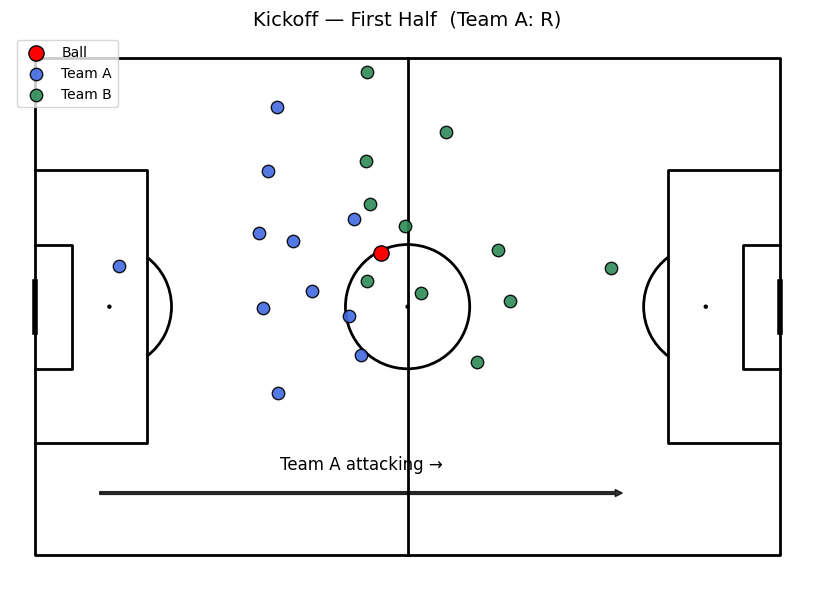

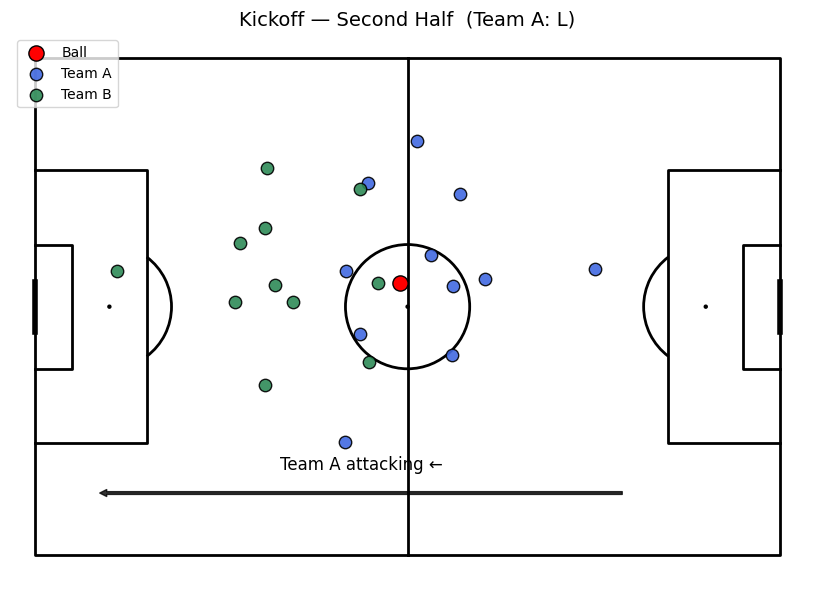

In [9]:
# ----------------------------
# Helpers
# ----------------------------

def rescale_to_pitch(df,
                     x_min=-52, x_max=52,
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):
    """Scale & shift SkillCorner coords to FIFA 105x68 (origin at bottom-left)."""
    df = df.copy()
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    return df

def get_kickoff_frame(match_data: pd.DataFrame, period: int) -> pd.DataFrame:
    """Return kickoff frame for given half using match clock; fallback to first non-null time frame."""
    tstr = "00:00:00.00" if period == 1 else "00:45:00.00"
    kf = match_data[(match_data["period"] == period) & (match_data["time"] == tstr)]
    if kf.empty:
        period_df = match_data[(match_data["period"] == period) & match_data["time"].notna()]
        if period_df.empty:
            return pd.DataFrame(columns=match_data.columns)
        first_frame = period_df["frame"].min()
        kf = period_df[period_df["frame"] == first_frame]
    return kf.copy()

def derive_team_rosters_from_kickoff(kickoff_df: pd.DataFrame):
    """Define Team A/B ONCE from 1st-half kickoff by splitting on median x (native coords)."""
    players = kickoff_df[~kickoff_df["is_ball"]]
    medx = players["x"].median()
    team_a_ids = set(players.loc[players["x"] <= medx, "player_id"].unique())
    team_b_ids = set(players.loc[players["x"] >  medx, "player_id"].unique())
    return team_a_ids, team_b_ids

def assign_teams(df: pd.DataFrame, team_a_ids: set, team_b_ids: set) -> pd.DataFrame:
    """Tag each row with fixed 'team' based on rosters defined at 1st-half kickoff."""
    df = df.copy()
    def lab(pid, is_ball):
        if is_ball: return "Ball"
        if pid in team_a_ids: return "Team A"
        if pid in team_b_ids: return "Team B"
        return "Unknown"
    df["team"] = df.apply(lambda r: lab(r["player_id"], r["is_ball"]), axis=1)
    return df

def attack_dir_from_kickoff(kickoff_rescaled: pd.DataFrame, team_label="Team A"):
    """
    Infer attack direction for a team at kickoff (rescaled coords).
    If Team A's mean x < Team B's mean x -> Team A is on the left half -> attacks RIGHT ("R").
    Else -> attacks LEFT ("L").
    """
    mean_a = kickoff_rescaled.loc[kickoff_rescaled["team"] == team_label, "x_rescaled"].mean()
    mean_b = kickoff_rescaled.loc[kickoff_rescaled["team"] == ("Team B" if team_label=="Team A" else "Team A"), "x_rescaled"].mean()
    return "R" if mean_a < mean_b else "L", mean_a, mean_b

def plot_kickoff_with_attack(kickoff_df_rescaled, attack_dir, title):
    """Plot players at kickoff with an arrow showing Team A attack direction."""
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(9, 6))
    colors = {"Team A": "royalblue", "Team B": "seagreen", "Ball": "red", "Unknown": "gray"}

    # scatter players/ball
    for team, grp in kickoff_df_rescaled.groupby("team"):
        if team == "Ball":
            ax.scatter(grp["x_rescaled"], grp["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")
        else:
            ax.scatter(grp["x_rescaled"], grp["y_rescaled"], c=colors.get(team, "gray"),
                       s=80, alpha=0.9, edgecolors="k", label=team)

    # arrow for Team A
    y_arrow = 70
    if attack_dir == "R":
        # arrow points from x=10 to x=95 (left -> right)
        ax.annotate("", xy=(95, y_arrow), xytext=(10, y_arrow),
                    arrowprops=dict(facecolor="black", arrowstyle="simple", alpha=0.8))
        ax.text(52.5, 67, "Team A attacking →", ha="center", va="bottom", fontsize=12)
    else:
        # arrow points from x=95 to x=10 (right -> left)
        ax.annotate("", xy=(10, y_arrow), xytext=(95, y_arrow),
                    arrowprops=dict(facecolor="black", arrowstyle="simple", alpha=0.8))
        ax.text(52.5, 67, "Team A attacking ←", ha="center", va="bottom", fontsize=12)

    ax.set_title(title + f"  (Team A: {attack_dir})", fontsize=14)
    ax.legend(loc="upper left")
    plt.show()

# ----------------------------
# Apply to one match
# ----------------------------

# pick a match
match_id = tracking["match_id"].iloc[1]
match_data = tracking[tracking["match_id"] == match_id].copy()

# get kickoff frames
kickoff1 = get_kickoff_frame(match_data, period=1)
kickoff2 = get_kickoff_frame(match_data, period=2)

# define Team A/B once from 1st-half kickoff (native coords)
team_a_ids, team_b_ids = derive_team_rosters_from_kickoff(kickoff1)

# tag teams in both kickoffs, then rescale
kickoff1 = assign_teams(kickoff1, team_a_ids, team_b_ids)
kickoff2 = assign_teams(kickoff2, team_a_ids, team_b_ids)
kickoff1_res = rescale_to_pitch(kickoff1)
kickoff2_res = rescale_to_pitch(kickoff2)

# infer Team A attack direction per half (robust: compare mean x of Team A vs Team B)
dir_p1, mA1, mB1 = attack_dir_from_kickoff(kickoff1_res, "Team A")
dir_p2, mA2, mB2 = attack_dir_from_kickoff(kickoff2_res, "Team A")
print(f"1st half means (Team A, Team B): {mA1:.2f}, {mB1:.2f} -> Team A attacks {dir_p1}")
print(f"2nd half means (Team A, Team B): {mA2:.2f}, {mB2:.2f} -> Team A attacks {dir_p2}")

# visualize
plot_kickoff_with_attack(kickoff1_res, dir_p1, "Kickoff — First Half")
plot_kickoff_with_attack(kickoff2_res, dir_p2, "Kickoff — Second Half")


## 7. Coordinate Transformation

Most providers have their own coordinate system.  
SkillCorner uses:  
- X ∈ [-52, 52]  
- Y ∈ [-34, 34]  

We want to transform into **FIFA standard (105 × 68 meters)**:  
- X ∈ [0, 105]  
- Y ∈ [0, 68]  

Benefits:  
- 📏 Units in meters → easier to interpret  
- 🧠 ML models trained on normalized input  
- 🏟️ Perfect match with `mplsoccer` pitch visuals  


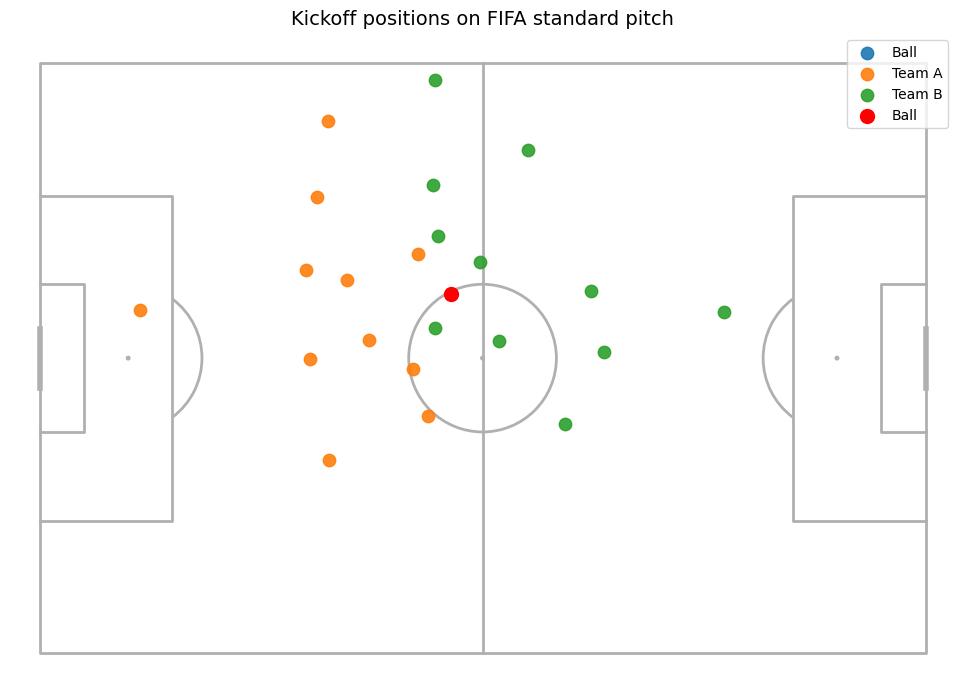

In [10]:
def rescale_to_pitch(df,
                     x_min=-52, x_max=52,
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):
    df = df.copy()
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    return df

# Apply to kickoff frame for visualization
kickoff1_scaled = rescale_to_pitch(kickoff1)

# Plot rescaled frame
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68)
fig, ax = pitch.draw(figsize=(10,7))

for team, group in kickoff1_scaled.groupby("team"):
    ax.scatter(group["x_rescaled"], group["y_rescaled"],
               label=team, s=80, alpha=0.9)

ax.scatter(kickoff1_scaled.loc[kickoff1_scaled["team"]=="Ball", "x_rescaled"],
           kickoff1_scaled.loc[kickoff1_scaled["team"]=="Ball", "y_rescaled"],
           c="red", s=100, label="Ball")

ax.set_title("Kickoff positions on FIFA standard pitch", fontsize=14)
ax.legend()
plt.show()


## 8) Normalize attack direction (one match)

Goal:
1) Identify **Team A** and **Team B** once at 1st-half kickoff (so colors don’t “follow the left side”).
2) Infer **Team A’s attack direction** at each half’s kickoff (R = right, L = left).
3) Add two new columns to `match_data`:
   - `team` ∈ {Team A, Team B, Ball}
   - `attack_dir` ∈ {R, L} (per row, based on the row’s half)
4) Create normalized coordinates `x_norm, y_norm` so **Team A always attacks →**.

Why do this?
- Aggregations (heatmaps, passing maps) become comparable across halves/matches.
- Coach/scout visuals are consistent and easier to interpret.


In [11]:
# --- 0) Small helpers (self-contained) ---

def rescale_to_pitch(df,
                     x_min=-52, x_max=52,  # SkillCorner native
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):  # FIFA
    """Scale & shift SkillCorner coords to FIFA 105x68 (origin bottom-left)."""
    df = df.copy()
    df["x_fifa"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_fifa"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    return df

def get_kickoff_frame(match_df: pd.DataFrame, period: int) -> pd.DataFrame:
    """Return kickoff frame rows (all players+ball) for a period; fallback to first non-null time frame."""
    tstr = "00:00:00.00" if period == 1 else "00:45:00.00"
    kf = match_df[(match_df["period"] == period) & (match_df["time"] == tstr)]
    if kf.empty:
        cand = match_df[(match_df["period"] == period) & match_df["time"].notna()]
        if cand.empty:
            return pd.DataFrame(columns=match_df.columns)
        first_frame = cand["frame"].min()
        kf = cand[cand["frame"] == first_frame]
    return kf.copy()

def derive_team_rosters_from_kickoff(kickoff_df: pd.DataFrame):
    """
    Define Team A/B ONCE from 1st-half kickoff (native coords):
    Team A = players with x <= median_x; Team B = x > median_x. Ball excluded.
    """
    players = kickoff_df[~kickoff_df["is_ball"]]
    medx = players["x"].median()
    team_a_ids = set(players.loc[players["x"] <= medx, "player_id"].unique())
    team_b_ids = set(players.loc[players["x"] >  medx, "player_id"].unique())
    return team_a_ids, team_b_ids

def assign_teams(df: pd.DataFrame, team_a_ids: set, team_b_ids: set) -> pd.DataFrame:
    """Tag each row with fixed 'team' based on rosters from 1st-half kickoff."""
    df = df.copy()
    def lab(pid, is_ball):
        if is_ball: return "Ball"
        if pid in team_a_ids: return "Team A"
        if pid in team_b_ids: return "Team B"
        return "Unknown"
    df["team"] = df.apply(lambda r: lab(r["player_id"], r["is_ball"]), axis=1)
    return df

def infer_attack_dir_at_kickoff(kickoff_fifa: pd.DataFrame, team_label="Team A"):
    """
    Compare mean x_fifa of Team A vs Team B at kickoff:
    If Team A mean < Team B mean, Team A starts left → attacks RIGHT ("R"); else "L".
    """
    mean_a = kickoff_fifa.loc[kickoff_fifa["team"] == team_label, "x_fifa"].mean()
    mean_b = kickoff_fifa.loc[kickoff_fifa["team"] == ("Team B" if team_label=="Team A" else "Team A"), "x_fifa"].mean()
    return "R" if mean_a < mean_b else "L"


In [12]:
# --- 1) Select ONE match and prepare match_data ---

match_id = tracking["match_id"].iloc[0]                     # choose a match
match_data = tracking[tracking["match_id"] == match_id].copy()

# Get kickoff frames
kickoff1 = get_kickoff_frame(match_data, period=1)          # 1st half
kickoff2 = get_kickoff_frame(match_data, period=2)          # 2nd half

# Derive fixed rosters ONCE (native coords)
team_a_ids, team_b_ids = derive_team_rosters_from_kickoff(kickoff1)

# Assign team labels across the whole match
match_data = assign_teams(match_data, team_a_ids, team_b_ids)

# Rescale entire match to FIFA coords (x_fifa, y_fifa)
match_data = rescale_to_pitch(match_data)

# Also rescale kickoff frames for direction inference
kickoff1 = rescale_to_pitch(assign_teams(kickoff1, team_a_ids, team_b_ids))
kickoff2 = rescale_to_pitch(assign_teams(kickoff2, team_a_ids, team_b_ids))

# Infer Team A attack direction per half
dir_p1 = infer_attack_dir_at_kickoff(kickoff1, "Team A")    # "R" or "L"
dir_p2 = infer_attack_dir_at_kickoff(kickoff2, "Team A")    # "R" or "L"

# Attach per-row attack_dir (by period)
match_data["attack_dir"] = np.where(match_data["period"] == 1, dir_p1,
                             np.where(match_data["period"] == 2, dir_p2, np.nan))

print(f"[{match_id}] Team A attack direction — 1st half: {dir_p1}, 2nd half: {dir_p2}")
match_data[["period","frame","player_id","team","attack_dir","x_fifa","y_fifa"]].head()


[2014987] Team A attack direction — 1st half: R, 2nd half: L


,period,frame,player_id,team,attack_dir,x_fifa,y_fifa
0,1,10,10662,Team A,R,13.549038,33.43
1,1,10,698827,Team A,R,36.023077,28.12
2,1,10,531576,Team A,R,37.608173,18.24
3,1,10,6823,Team A,R,36.649038,40.15
4,1,10,24300,Team A,R,39.041827,7.83


**Normalize coordinates** so that Team A always attacks **left → right**.  
If `attack_dir == 'L'` in a half, flip *all* rows in that half (both teams + ball), so the orientation aligns.


In [13]:
# --- 2) Normalize coordinates to make Team A always attack right (→) ---

match_data["x_norm"] = match_data["x_fifa"]
match_data["y_norm"] = match_data["y_fifa"]

need_flip_p1 = (dir_p1 == "L")
need_flip_p2 = (dir_p2 == "L")

# flip half 1 if needed
mask_p1 = (match_data["period"] == 1) & need_flip_p1
match_data.loc[mask_p1, "x_norm"] = 105 - match_data.loc[mask_p1, "x_fifa"]
match_data.loc[mask_p1, "y_norm"] =  68 - match_data.loc[mask_p1, "y_fifa"]

# flip half 2 if needed
mask_p2 = (match_data["period"] == 2) & need_flip_p2
match_data.loc[mask_p2, "x_norm"] = 105 - match_data.loc[mask_p2, "x_fifa"]
match_data.loc[mask_p2, "y_norm"] =  68 - match_data.loc[mask_p2, "y_fifa"]

# quick sanity check at kickoffs: Team A should be left of Team B in BOTH halves now
k1_norm = match_data[(match_data["period"]==1) & (match_data["time"]=="00:00:00.00")]
k2_norm = match_data[(match_data["period"]==2) & (match_data["time"]=="00:45:00.00")]

mA1 = k1_norm.loc[k1_norm["team"]=="Team A","x_norm"].mean()
mB1 = k1_norm.loc[k1_norm["team"]=="Team B","x_norm"].mean()
mA2 = k2_norm.loc[k2_norm["team"]=="Team A","x_norm"].mean()
mB2 = k2_norm.loc[k2_norm["team"]=="Team B","x_norm"].mean()

print(f"Kickoff check (normalized):\n  1st half Team A vs B mean x: {mA1:.1f} vs {mB1:.1f}\n  2nd half Team A vs B mean x: {mA2:.1f} vs {mB2:.1f}")


Kickoff check (normalized):
  1st half Team A vs B mean x: 40.2 vs 65.2
  2nd half Team A vs B mean x: 41.7 vs 65.8


**What you should see in the check above:**
- After normalization, at both kickoffs **Team A mean x_norm < Team B mean x_norm** (Team A starts on the left in both halves).
- This guarantees that any aggregate visuals (e.g., heatmaps) are aligned left→right for Team A.


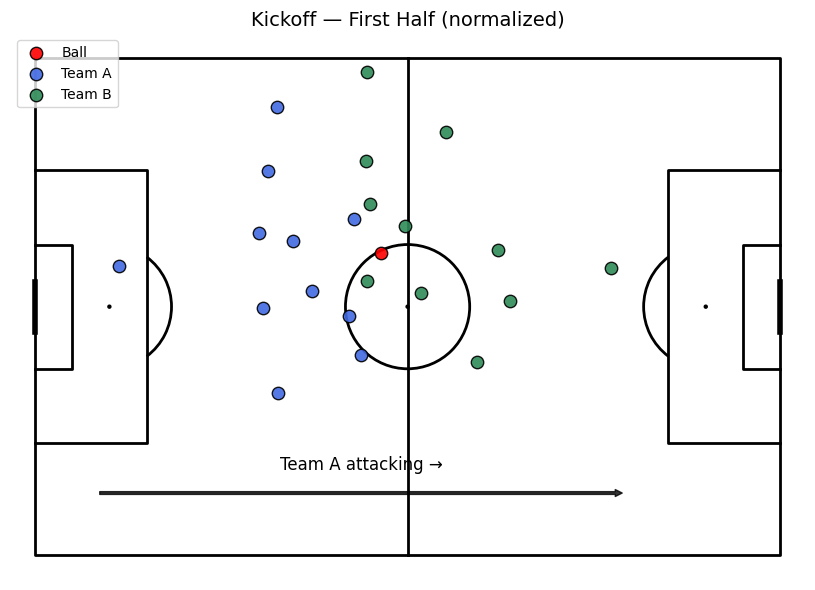

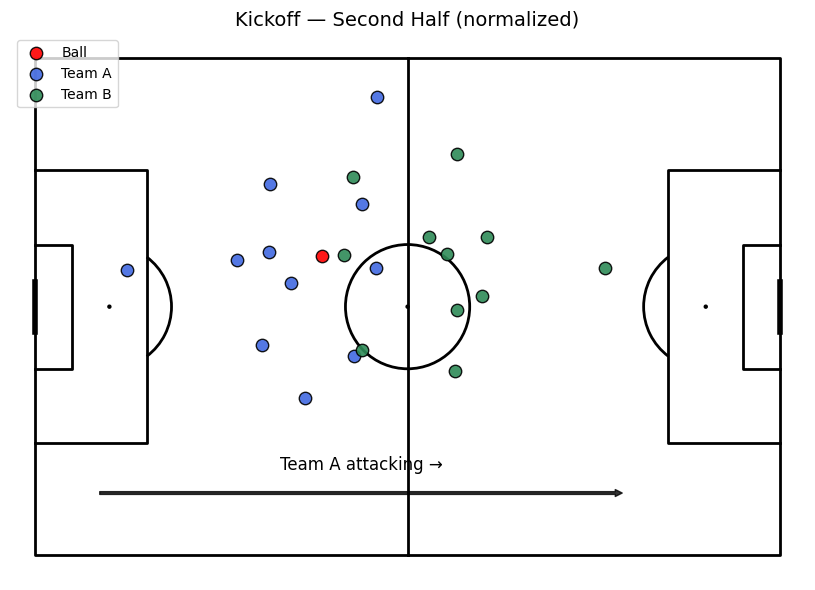

In [14]:

def plot_kickoff_with_attack_norm(df, period, title):
    """Plot kickoff positions (normalized) with arrow showing Team A attack →"""
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(9, 6))
    colors = {"Team A": "royalblue", "Team B": "seagreen", "Ball": "red"}

    # filter kickoff frame of given half
    if period == 1:
        kickoff = df[(df["period"]==1) & (df["time"]=="00:00:00.00")]
    elif period == 2:
        kickoff = df[(df["period"]==2) & (df["time"]=="00:45:00.00")]
    else:
        raise ValueError("Only periods 1 or 2 supported")

    # plot dots
    for team, grp in kickoff.groupby("team"):
        ax.scatter(grp["x_norm"], grp["y_norm"],
                   c=colors.get(team, "gray"), s=80, alpha=0.9, edgecolors="k", label=team)

    # attack arrow (always right, because normalized)
    y_arrow = 70
    ax.annotate("", xy=(95, y_arrow), xytext=(10, y_arrow),
                arrowprops=dict(facecolor="black", arrowstyle="simple", alpha=0.8))
    ax.text(52.5, 67, "Team A attacking →", ha="center", va="bottom", fontsize=12)

    ax.set_title(title, fontsize=14)
    ax.legend(loc="upper left")
    plt.show()

# --- Plot both halves ---
plot_kickoff_with_attack_norm(match_data, period=1, title="Kickoff — First Half (normalized)")
plot_kickoff_with_attack_norm(match_data, period=2, title="Kickoff — Second Half (normalized)")


## 9) Derive football-ready metrics: speed & acceleration

One of the first things to compute from tracking data is **player speed**:
- **Speed (m/s)** = how fast a player is moving at each frame.
- **Acceleration (m/s²)** = how quickly they change speed.

Why is this useful?
- Identifying sprints, presses, recovery runs.
- Linking physical output to tactical moments (pressing triggers, counter-attacks).
- Comparing players’ intensity across matches.

We will:
1. Use the **normalized coordinates** (`x_norm`, `y_norm`) so direction is consistent.  
2. Convert the `time` column into seconds.  
3. Compute **frame-to-frame displacement / time difference** for each player.  
4. Plot histograms of speed values to see typical distributions.


In [15]:
# --- Helper: convert time string to seconds ---
def parse_time_to_seconds(tstr):
    if pd.isna(tstr):
        return np.nan
    hh, mm, ss = tstr.split(":")
    return int(hh)*3600 + int(mm)*60 + float(ss)

# --- Add t_seconds column ---
match_data["t_seconds"] = match_data["time"].apply(parse_time_to_seconds)

# --- Compute speed & acceleration ---
match_data = match_data.sort_values(["player_id","period","frame"])

dx = match_data.groupby("player_id")["x_norm"].diff()
dy = match_data.groupby("player_id")["y_norm"].diff()
dt = match_data.groupby("player_id")["t_seconds"].diff()

# speed (m/s)
speed = np.sqrt(dx**2 + dy**2) / dt
match_data["speed_mps"] = speed.fillna(0)

# acceleration (m/s²)
accel = match_data.groupby("player_id")["speed_mps"].diff() / dt
match_data["accel_mps2"] = accel.fillna(0)

match_data[match_data.player_id > 0][["player_id","period","frame","x_norm","y_norm","speed_mps","accel_mps2"]].head()


,player_id,period,frame,x_norm,y_norm,speed_mps,accel_mps2
17,2190,1,10,62.162019,37.72,0.000000,0.000000
40,2190,1,11,62.141827,37.73,0.225328,2.253285
63,2190,1,12,62.141827,37.74,0.100000,-1.253285
86,2190,1,13,62.131731,37.74,0.100962,0.009615
109,2190,1,14,62.131731,37.74,0.000000,-1.009615


### Speed distributions

Let’s check how speeds are distributed across the match.  
We expect:
- Most values around **2–5 m/s** (jogging, light movement).  
- Fewer values above **7 m/s** (sprints).  
- Outliers can be ball coordinates or tracking errors.


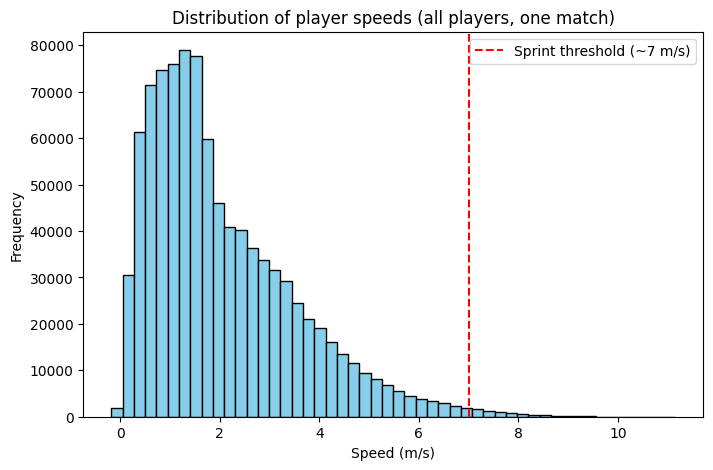

In [16]:
plt.figure(figsize=(8,5))
plt.hist(match_data.loc[~match_data["is_ball"], "speed_mps"], bins=50,
         color="skyblue", edgecolor="k")
plt.axvline(7, color="red", linestyle="--", label="Sprint threshold (~7 m/s)")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")
plt.title("Distribution of player speeds (all players, one match)")
plt.legend()
plt.show()


## 10) Team Structure & Shape Basics

A key advantage of tracking data is that we can measure **team structure**:
- **Convex hull** = the smallest polygon that contains all players (like stretching a rubber band around them).
- **Voronoi diagram** = partitions the pitch into regions where each region belongs to the closest player.

These concepts help us understand:
- **Team compactness** (convex hull area).
- **Pitch control** and **spatial dominance** (Voronoi).
- How attacking/defending teams shape up at a given frame.

We’ll demonstrate both for one random frame.


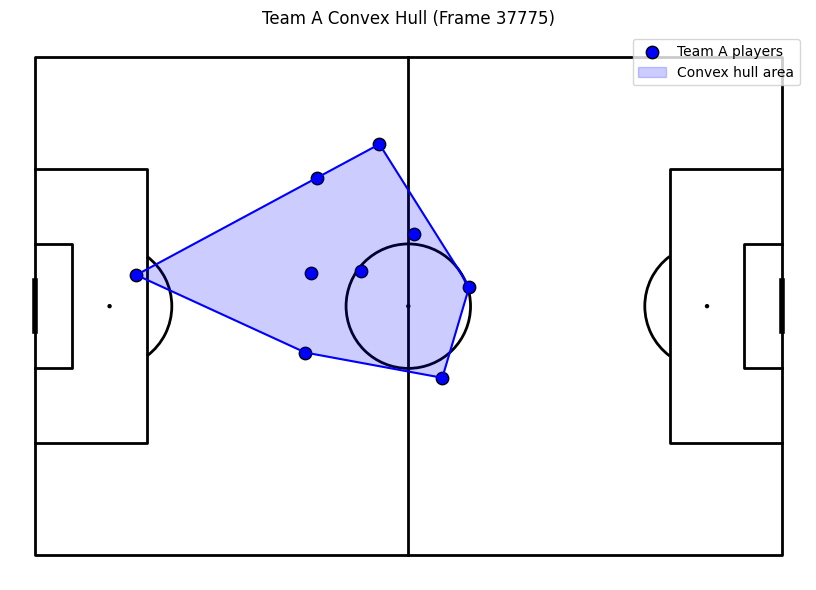

In [17]:
# pick one random frame from normalized data
frame_id = match_data["frame"].sample(1, random_state=1).iloc[0]
frame_df = match_data[(match_data["frame"] == frame_id) & (~match_data["is_ball"])]

# select Team A only
teamA = frame_df[frame_df["team"]=="Team A"]

# convex hull
points = teamA[["x_norm","y_norm"]].to_numpy()
hull = ConvexHull(points)

# plot
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9,6))

# scatter players
ax.scatter(teamA["x_norm"], teamA["y_norm"], c="blue", s=80, edgecolors="k", label="Team A players")

# draw hull polygon
for simplex in hull.simplices:
    ax.plot(points[simplex, 0], points[simplex, 1], "b-")

ax.fill(points[hull.vertices,0], points[hull.vertices,1], color="blue", alpha=0.2, label="Convex hull area")
ax.set_title(f"Team A Convex Hull (Frame {frame_id})")
ax.legend()
plt.show()


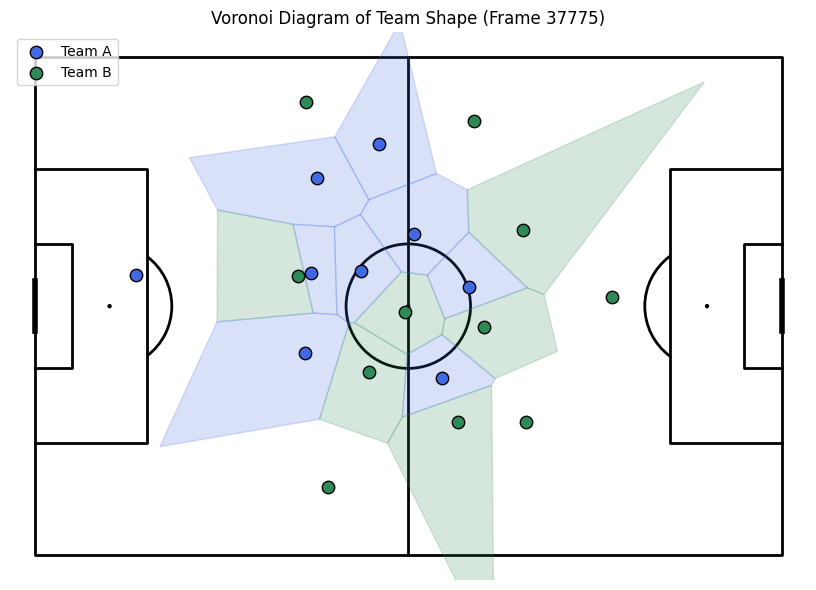

In [18]:
# filter only players with valid team labels
frame_df_valid = frame_df[frame_df["team"].isin(["Team A","Team B"])]

points_all = frame_df_valid[["x_norm","y_norm"]].to_numpy()
teams = frame_df_valid["team"].to_numpy()

vor = Voronoi(points_all)

# plot
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9,6))

colors = {"Team A":"royalblue", "Team B":"seagreen"}

for region_index, player_team in zip(vor.point_region, teams):
    region = vor.regions[region_index]
    if not -1 in region and len(region) > 0:
        polygon = [vor.vertices[i] for i in region]
        ax.fill(*zip(*polygon), color=colors[player_team], alpha=0.2)

# plot players
for team in ["Team A","Team B"]:
    df_team = frame_df_valid[frame_df_valid["team"]==team]
    ax.scatter(df_team["x_norm"], df_team["y_norm"],
               c=colors[team], s=80, edgecolors="k", label=team)

ax.set_title(f"Voronoi Diagram of Team Shape (Frame {frame_id})")
ax.legend()
plt.show()


### What do we learn?
- **Convex hull**: tells us how spread or compact a team is (defensive block vs wide attacking shape).  
- **Voronoi**: shows which areas of the pitch each player is “closest” to — a first step towards **pitch control models**.  

👉 These shapes form the building blocks for **defensive line detection, compactness measures, and pitch control analysis**.


# 📚 Section 11: Synchronizing Events with Tracking

## 11.1 Why Synchronization Matters

We now have two worlds of data:

Tracking data (continuous): every player + ball position at every frame.

Dynamic events (discrete): football actions (passes, carries, shots, duels, etc.), each referencing specific frame_start and frame_end.

To analyze tactics properly, we need to merge these two so that:

Each event has the freeze frame of all players at its start (and optionally at its end).

We know exactly where the teammates and opponents were positioned.

We can compute features such as defensive line, distance to defenders, or passing options.

## 11.2 Best Practice: Use Frame IDs

⚠️ Never merge purely based on time (timestamps), because:

- They may have rounding/encoding errors.

- Different data sources may have slight clock drifts.

✅ Skillcorner already sync the data and provides a frame mapping in the dynamic events. Therefore we merge on frame, since this is the synchronization key between events and tracking.

- Each event has frame_start and frame_end.

- Each row in tracking has a frame.

## 11.3 Implementation

We’ll create a freeze-frame DataFrame that enriches each event with the positions of all players + ball at the relevant frame.

In [19]:

all_events = {}
all_tracking = {}

for match_id in df_matches["id"].values:
    # Load events
    try:
        df_events = pd.read_parquet(BASE_DIR / 'dynamic' / f"{match_id}.parquet"
        )
    except:
        print(f"⚠️ No dynamic events for match {match_id}")
        continue

    # Subset tracking
    df_tracking = tracking[tracking["match_id"] == match_id]

    all_events[match_id] = df_events
    all_tracking[match_id] = df_tracking

    print(f"Match {match_id}: Events {df_events.shape}, Tracking {df_tracking.shape}")


Match 1021404: Events (5926, 294), Tracking (0, 9)
Match 1036527: Events (5369, 294), Tracking (0, 9)
Match 1048195: Events (5298, 294), Tracking (0, 9)
Match 1064327: Events (4987, 294), Tracking (0, 9)
Match 1096879: Events (5286, 294), Tracking (0, 9)
Match 1103734: Events (5760, 294), Tracking (0, 9)
Match 1114154: Events (5216, 294), Tracking (0, 9)
Match 1121546: Events (6623, 294), Tracking (0, 9)
Match 1129394: Events (5769, 294), Tracking (0, 9)
Match 1137151: Events (5359, 294), Tracking (0, 9)
Match 1146865: Events (5268, 294), Tracking (0, 9)
Match 1184210: Events (5224, 294), Tracking (0, 9)
Match 1193411: Events (5300, 294), Tracking (0, 9)
Match 1204769: Events (5514, 294), Tracking (0, 9)
Match 1227667: Events (4808, 294), Tracking (0, 9)
Match 1234494: Events (6035, 294), Tracking (0, 9)
Match 1242274: Events (5332, 294), Tracking (0, 9)
⚠️ No dynamic events for match 1274919
Match 1281971: Events (5927, 294), Tracking (0, 9)
Match 1287842: Events (5939, 294), Tracking

## 11.4 Freeze-Frame Construction

We now join tracking onto events.

For each event_id, get the frame_start (or frame_end).

Attach all tracking rows where frame == frame_start.

In [20]:
# --- Build freeze frames for all matches ---
all_freezes = []

for match_id in df_matches["id"].values:
    if match_id not in all_events or match_id not in all_tracking:
        continue

    df_events = all_events[match_id]
    df_tracking = all_tracking[match_id]

    # 1. Only player_possession events
    df_events_pos = df_events[df_events["event_type"] == "player_possession"]

    # 2. Select key columns
    df_events_end = df_events_pos[
        [
            "event_id", "match_id", "frame_start", "frame_end",
            "time_start", "time_end", "team_id", "attacking_side",
            "player_id", "player_name", "team_shortname",
            "start_type", "end_type",
            "x_start", "y_start", "x_end", "y_end"
        ]
    ]

    # 3. Merge with tracking on (match_id, frame=frame_end)
    df_freeze_start = df_tracking.merge(
        df_events_end,
        left_on=["match_id", "frame"],
        right_on=["match_id", "frame_end"],
        how="inner"
    )

    print(f"Match {match_id}: Freeze-frame {df_freeze_start.shape}")

    all_freezes.append(df_freeze_start)

# 4. Combine all matches
df_freeze_start = pd.concat(all_freezes, ignore_index=True)
print("Total freeze-frame DataFrame:", df_freeze_start.shape)


Match 1021404: Freeze-frame (0, 25)
Match 1036527: Freeze-frame (0, 25)
Match 1048195: Freeze-frame (0, 25)
Match 1064327: Freeze-frame (0, 25)
Match 1096879: Freeze-frame (0, 25)
Match 1103734: Freeze-frame (0, 25)
Match 1114154: Freeze-frame (0, 25)
Match 1121546: Freeze-frame (0, 25)
Match 1129394: Freeze-frame (0, 25)
Match 1137151: Freeze-frame (0, 25)
Match 1146865: Freeze-frame (0, 25)
Match 1184210: Freeze-frame (0, 25)
Match 1193411: Freeze-frame (0, 25)
Match 1204769: Freeze-frame (0, 25)
Match 1227667: Freeze-frame (0, 25)
Match 1234494: Freeze-frame (0, 25)
Match 1242274: Freeze-frame (0, 25)
Match 1281971: Freeze-frame (0, 25)
Match 1287842: Freeze-frame (0, 25)
Match 1301584: Freeze-frame (0, 25)
Match 1307205: Freeze-frame (0, 25)
Match 1314538: Freeze-frame (0, 25)
Match 1320692: Freeze-frame (0, 25)
Match 1340201: Freeze-frame (0, 25)
Match 1365685: Freeze-frame (0, 25)
Match 1374493: Freeze-frame (0, 25)
Match 1380976: Freeze-frame (0, 25)
Match 1385604: Freeze-frame 

In [21]:
df_freeze_start.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id_x', 'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start', 'frame_end',
       'time_start', 'time_end', 'team_id', 'attacking_side', 'player_id_y', 'player_name', 'team_shortname', 'start_type', 'end_type',
       'x_start', 'y_start', 'x_end', 'y_end'],
      dtype='object')

## Players relation to ball holder

Enrich Freeze Frame Data with Player Metadata

When analyzing football freeze frames, we need to know not just the event context (possession team, ball carrier, event type), but also who each player is (name, team, position group, etc.).

This information usually comes from match metadata files. In your dataset, those are JSON files in meta/, one per match.

Step 1. Load Player Metadata for All Matches

We’ll loop through all JSON meta files and create a player-to-team mapping.


In [22]:
META_DIR = BASE_DIR / "meta"

def load_meta_mapping(match_id: int):
    """
    Load meta JSON for a given match and return player metadata DataFrame.
    """
    fpath = META_DIR / f"{match_id}.json"
    if not fpath.exists():
        print(f"⚠️ No meta file for match {match_id}")
        return pd.DataFrame()

    with open(fpath, "r",encoding="utf-8") as f:
        meta = json.load(f)

    home_team, away_team = meta["home_team"], meta["away_team"]

    records = []
    for p in meta.get("players", []):
        if "id" not in p:  # skip if malformed
            continue
        team_name = home_team["name"] if p["team_id"] == home_team["id"] else away_team["name"]
        team_shortname = home_team["short_name"] if p["team_id"] == home_team["id"] else away_team["short_name"]

        records.append({
            "match_id": meta["id"],
            "player_id": p["id"],
            "player_short_name": p.get("short_name"),
            "player_team_id": p["team_id"],
            "player_team_name": team_name,
            "player_team_shortname": team_shortname,
            "player_position_group": p["player_role"]["position_group"] if p.get("player_role") else None,
            "player_role": p["player_role"]["name"] if p.get("player_role") else None
        })

    return pd.DataFrame(records)


In [23]:
all_meta = []

for match_id in df_matches["id"].values:
    df_meta = load_meta_mapping(match_id)
    if not df_meta.empty:
        all_meta.append(df_meta)

df_meta_all = pd.concat(all_meta, ignore_index=True)
print("Meta shape:", df_meta_all.shape)
df_meta_all.head()


Meta shape: (4385, 8)


,match_id,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role
0,1021404,12218,A. Tchouaméni,262,Real Madrid CF,Real Madrid,Midfield,Defensive Midfield
1,1021404,12251,F. Valverde,262,Real Madrid CF,Real Madrid,Midfield,Right Midfield
2,1021404,12253,Vinícius Júnior,262,Real Madrid CF,Real Madrid,Center Forward,Center Forward
3,1021404,25739,Iñigo Ruiz de Galarreta,273,Athletic Club de Bilbao,Athletic Bilbao,Midfield,Right Defensive Midfield
4,1021404,13902,Gorka Guruzeta,273,Athletic Club de Bilbao,Athletic Bilbao,Center Forward,Center Forward


Step 2. Build a Master Metadata Table

We loop over all unique match_ids from your df_freeze_start and concatenate.

Step 3. Merge Metadata into Freeze Frame

Now merge on match_id and player_id_x (since that’s the player column in your freeze frames).

In [24]:
df_freeze_start_enriched = df_freeze_start.merge(
    df_meta_all,
    left_on=["match_id", "player_id_x"],   # from tracking
    right_on=["match_id", "player_id"],    # from meta
    how="left"
)

print("Enriched freeze-frame:", df_freeze_start_enriched.shape)
df_freeze_start_enriched.head()


Enriched freeze-frame: (118738, 32)


,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role
0,2014987,00:00:01.30,23,1,10662,False,False,-40.51,-0.50,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,10662.0,Vicente Guaita,285.0,RC Celta de Vigo,Celta Vigo,Other,Goalkeeper
1,2014987,00:00:01.30,23,1,698827,False,False,-16.15,-7.56,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,698827.0,Yoel Lago,285.0,RC Celta de Vigo,Celta Vigo,Central Defender,Center Back
2,2014987,00:00:01.30,23,1,531576,False,False,-14.54,-16.27,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,531576.0,Javi Rodríguez,285.0,RC Celta de Vigo,Celta Vigo,Central Defender,Right Center Back
3,2014987,00:00:01.30,23,1,6823,False,False,-15.47,4.96,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,6823.0,Marcos Alonso,285.0,RC Celta de Vigo,Celta Vigo,Central Defender,Left Center Back
4,2014987,00:00:01.30,23,1,24300,False,False,-12.91,-27.01,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,24300.0,Sergio Carreira,285.0,RC Celta de Vigo,Celta Vigo,Full Back,Right Wing Back


In [25]:
df_freeze_start_enriched.shape

(118738, 32)

In [26]:
def rescale_to_pitch(df,
                     x_min=-52, x_max=52,
                     y_min=-34, y_max=34,
                     target_x=105, target_y=68):
    """
    Scale & shift SkillCorner coords (centered) to mplsoccer/StatsBomb convention:
    - x: 0 → 105
    - y: 0 → 68
    Origin becomes bottom-left corner.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns ['x','y'] (and optionally ['x_end','y_end']).
    """
    df = df.copy()

    # Core positions
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y

    # If pass/shot end coords exist, scale them too
    if "x_end" in df.columns and "y_end" in df.columns:
        df["x_end_rescaled"] = (df["x_end"] - x_min) / (x_max - x_min) * target_x
        df["y_end_rescaled"] = (df["y_end"] - y_min) / (y_max - y_min) * target_y

    return df


In [27]:
df_freeze_start_enriched = rescale_to_pitch(df_freeze_start_enriched)

# Quick check
print(df_freeze_start_enriched[["x_rescaled","y_rescaled"]].describe())


          x_rescaled     y_rescaled
count  118738.000000  118738.000000
mean       51.158205      33.437468
std        25.280862      14.741653
min        -3.574038      -3.660000
25%        30.147115      23.290000
50%        50.612019      33.560000
75%        71.983053      43.360000
max       108.301442      72.540000


Plotting Match 2017232, Frame 5062


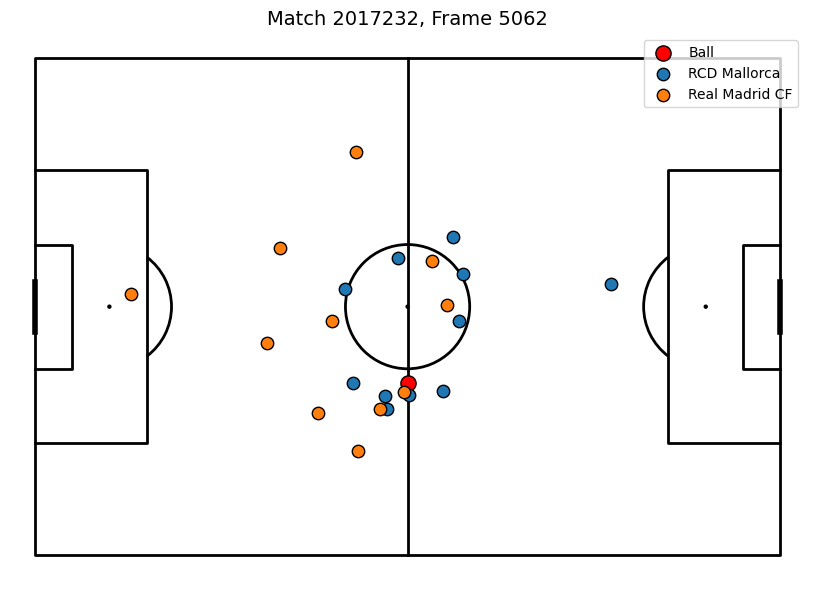

In [29]:

# Pick a random frame
random_row = df_freeze_start_enriched.sample(1).iloc[0]
match_id = random_row["match_id"]
frame_no = random_row["frame"]

frame_example = df_freeze_start_enriched[
    (df_freeze_start_enriched["match_id"] == match_id) &
    (df_freeze_start_enriched["frame"] == frame_no)
]

print(f"Plotting Match {match_id}, Frame {frame_no}")

# Initialize pitch
pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9, 6))

# Plot ball
ball = frame_example[frame_example["is_ball"] == True]
ax.scatter(ball["x_rescaled"], ball["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")

# Plot players by team
for team, group in frame_example[frame_example["is_ball"] == False].groupby("player_team_name"):
    ax.scatter(group["x_rescaled"], group["y_rescaled"], s=80, edgecolors="k", label=team)

# Add title and legend
ax.set_title(f"Match {match_id}, Frame {frame_no}", fontsize=14)
ax.legend()
plt.show()


# Section 12: Defensive Line Detection by Last Outfield Player

## 12.1 Why Defensive Lines?

Defensive line = the line formed by the last outfield defenders (usually center-backs).

Key for:

🏃 Offside detection

📊 Tactical compactness

📏 Measuring defensive block height

## 12.2 Step 1: Detect the Last Defender

For simplicity:

Exclude the goalkeeper (we’ll treat player_id of GK separately if available).

Take the maximum x-coordinate of defenders for the team that is not in possession.

If Team A is defending, last_defender_x = max(defenders’ x).

In [ ]:

def plot_defensive_line(frame_df, defending_team_name, defend_left=True):
    """
    Plot players on the pitch and add a dashed line for the last defender
    (2nd deepest player) of the defending_team.

    Parameters
    ----------
    frame_df : pd.DataFrame
        Freeze-frame tracking data for a single frame. Must contain:
        - x_rescaled, y_rescaled (mplsoccer coordinates: 0-105 x 0-68)
        - is_ball (True/False)
        - player_team_name
    defending_team_name : str
        The actual team name (e.g. "Real Madrid CF") to evaluate.
    defend_left : bool, default=True
        If True, team defends the left goal (x close to 0).
        If False, team defends the right goal (x close to 105).
    """
    frame_df = frame_df.copy()
    
    # Defensive players (exclude ball)
    defenders = frame_df[
        (frame_df["player_team_name"] == defending_team_name) & (frame_df["is_ball"] == False)
    ]
    
    if defenders.empty:
        print(f"No defenders found for {defending_team_name} in this frame")
        return
    
    # Sort defenders based on defending direction
    if defend_left:
        sorted_defenders = defenders.sort_values("x_rescaled")  # left side → smallest x
    else:
        sorted_defenders = defenders.sort_values("x_rescaled", ascending=False)  # right side → largest x
    
    # Defensive line = 2nd deepest player
    if len(sorted_defenders) >= 2:
        last_defender_x = sorted_defenders.iloc[1]["x_rescaled"] if defend_left else sorted_defenders.iloc[1]["x_rescaled"]
    else:
        last_defender_x = np.nan
    
    # --- Plotting ---
    pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
    fig, ax = pitch.draw(figsize=(9,6))
    
    # Plot ball
    ball = frame_df[frame_df["is_ball"]]
    ax.scatter(ball["x_rescaled"], ball["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")
    
    # Plot players by team
    for team, group in frame_df.groupby("player_team_name"):
        ax.scatter(group["x_rescaled"], group["y_rescaled"], s=80, alpha=0.9, edgecolors="k", label=team)
    
    # Defensive line
    if not np.isnan(last_defender_x):
        ax.axvline(last_defender_x, color="black", linestyle="--", linewidth=2, label="Defensive line")
    
    ax.set_title(f"Defensive line of {defending_team_name}", fontsize=14)
    ax.legend()
    plt.show()


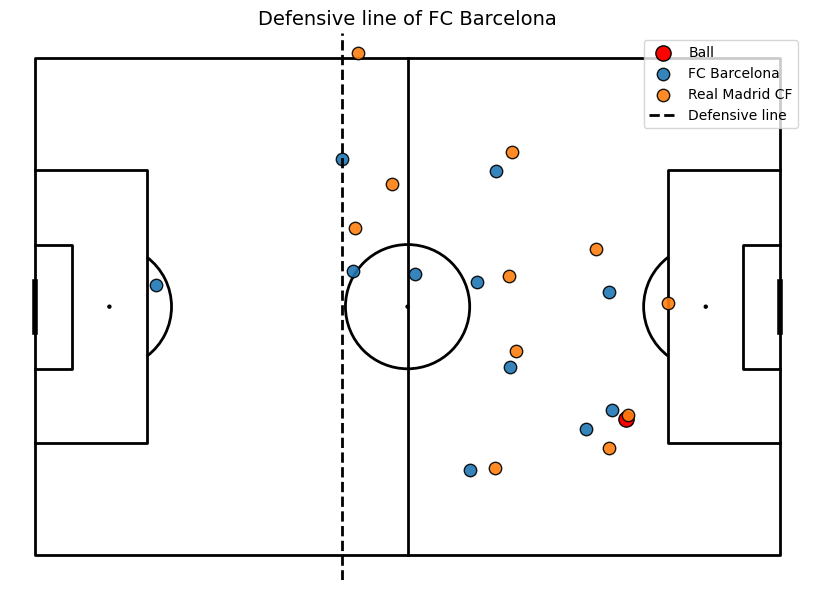

In [37]:
# Pick a random frame
random_row = df_freeze_start_enriched.sample(1).iloc[0]
match_id = random_row["match_id"]
frame_no = random_row["frame"]

frame_example = df_freeze_start_enriched[
    (df_freeze_start_enriched["match_id"] == match_id) &
    (df_freeze_start_enriched["frame"] == frame_no)
]

# Pick defending team from this frame
defending_team = frame_example.loc[~frame_example["is_ball"], "player_team_name"].unique()[0]

# Plot
plot_defensive_line(frame_example, defending_team_name=defending_team, defend_left=True)



In [102]:
df_freeze_start_enriched.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id_x', 'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start', 'frame_end',
       'time_start', 'time_end', 'team_id', 'attacking_side', 'player_id_y', 'player_name', 'team_shortname', 'start_type', 'end_type',
       'x_start', 'y_start', 'x_end', 'y_end', 'player_short_name', 'player_team_id', 'player_team_name', 'player_team_shortname',
       'player_position_group', 'player_role', 'x_rescaled', 'y_rescaled', 'x_end_rescaled', 'y_end_rescaled'],
      dtype='object')

In [38]:
df_freeze_start_enriched.team_shortname.value_counts()

team_shortname
Real Madrid      68497
Celta Vigo       12305
FC Barcelona     11753
Real Sociedad    10994
Sevilla FC        7875
RCD Mallorca      7314
Name: count, dtype: int64

In [36]:
df_freeze_start_enriched.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id_x', 'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start', 'frame_end',
       'time_start', 'time_end', 'team_id', 'attacking_side', 'player_id_y', 'player_name', 'team_shortname', 'start_type', 'end_type',
       'x_start', 'y_start', 'x_end', 'y_end', 'player_id', 'player_short_name', 'player_team_id', 'player_team_name',
       'player_team_shortname', 'player_position_group', 'player_role', 'x_rescaled', 'y_rescaled', 'x_end_rescaled', 'y_end_rescaled'],
      dtype='object')

In [39]:
df_freeze_start_enriched.attacking_side.value_counts()

attacking_side
right_to_left    62508
left_to_right    56230
Name: count, dtype: int64

# 📚 Section 13: Detecting Defensive Lines with Clustering

isolates Real Madrid’s out-of-possession frames,

normalizes direction so their own goal is always on the left,

trains a single KMeans model (k=3) on all defensive player x-positions, and

applies it back to any frame to draw the three defensive lines.

In [40]:
df_freeze_start_enriched

,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,2014987,00:00:01.30,23,1,10662,False,False,-40.51,-0.50,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,10662.0,Vicente Guaita,285.0,RC Celta de Vigo,Celta Vigo,Other,Goalkeeper,11.600481,33.50,52.247596,32.86
1,2014987,00:00:01.30,23,1,698827,False,False,-16.15,-7.56,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,698827.0,Yoel Lago,285.0,RC Celta de Vigo,Celta Vigo,Central Defender,Center Back,36.194712,26.44,52.247596,32.86
2,2014987,00:00:01.30,23,1,531576,False,False,-14.54,-16.27,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,531576.0,Javi Rodríguez,285.0,RC Celta de Vigo,Celta Vigo,Central Defender,Right Center Back,37.820192,17.73,52.247596,32.86
3,2014987,00:00:01.30,23,1,6823,False,False,-15.47,4.96,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,6823.0,Marcos Alonso,285.0,RC Celta de Vigo,Celta Vigo,Central Defender,Left Center Back,36.881250,38.96,52.247596,32.86
4,2014987,00:00:01.30,23,1,24300,False,False,-12.91,-27.01,8_0,23,23,00:01.3,00:01.3,262,right_to_left,44876,A. Güler,Real Madrid,unknown,pass,-0.25,-1.14,-0.25,-1.14,24300.0,Sergio Carreira,285.0,RC Celta de Vigo,Celta Vigo,Full Back,Right Wing Back,39.465865,6.99,52.247596,32.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118733,2018396,01:30:51.90,55219,2,44876,True,False,-17.83,-7.58,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,44876.0,A. Güler,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Right Forward,34.498558,26.42,15.225000,11.33
118734,2018396,01:30:51.90,55219,2,70520,True,False,-19.77,2.87,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,70520.0,Gonzalo García,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Right Forward,32.539904,36.87,15.225000,11.33
118735,2018396,01:30:51.90,55219,2,12253,True,False,-22.53,-20.20,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,12253.0,Vinícius Júnior,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Left Forward,29.753365,13.80,15.225000,11.33
118736,2018396,01:30:51.90,55219,2,6028,True,False,-36.31,-7.85,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,6028.0,K. Mbappé,262.0,Real Madrid CF,Real Madrid,Center Forward,Center Forward,15.840865,26.15,15.225000,11.33


In [41]:
# Step 1. Filter Real Madrid defensive frames

# We only want Real Madrid players when they are out of possession.


TARGET_TEAM = "Real Madrid"   # adjust if meta uses another name
PITCH_LENGTH = 105.0
HALF_LENGTH = PITCH_LENGTH / 2.0

# Defensive players: Real Madrid, not ball, and not in possession
rm_def_rows = df_freeze_start_enriched[
    (df_freeze_start_enriched["player_team_shortname"] == TARGET_TEAM) &
    (~df_freeze_start_enriched["is_ball"]) &
    (df_freeze_start_enriched["team_id"] != df_freeze_start_enriched["player_team_id"])  # ensures opponent has ball
].copy()



In [42]:
# Step 2. Normalization with attack_direction

def normalize_own_goal_left(df, target_team="Real Madrid"):
    """
    Flip Real Madrid's x so their own goal is always on the left (x=0).
    Uses the attack_direction column of the team in possession.
    """
    df = df.copy()

    # Determine if RM are defending left or right in each frame
    # If the possession team attacks "R", then RM defend "L", and vice versa.
    df["rm_defend_left"] = np.where(
        (df["player_team_name"] == target_team) & (~df["is_ball"]),
        np.where(df["attacking_side"] == "right_to_left", True, False),
        np.nan
    )

    # Forward fill per frame (so every RM row gets the same defend direction)
    df["rm_defend_left"] = df.groupby(["match_id","frame"])["rm_defend_left"].transform("max")

    # Apply flip: if RM defend right, flip coords to put their goal at x=0
    df["x_norm"] = np.where(df["rm_defend_left"], df["x_rescaled"], PITCH_LENGTH - df["x_rescaled"])
    df["y_norm"] = df["y_rescaled"]

    return df

rm_def_rows = normalize_own_goal_left(rm_def_rows)


In [43]:
rm_def_rows

,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled,rm_defend_left,x_norm,y_norm
310,2014987,00:00:35.00,360,1,10261,False,False,39.99,-2.01,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,10261.0,T. Courtois,262.0,Real Madrid CF,Real Madrid,Other,Goalkeeper,92.874519,31.99,48.703846,27.55,NaN,92.874519,31.99
311,2014987,00:00:35.00,360,1,12218,False,False,16.51,0.82,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,12218.0,A. Tchouaméni,262.0,Real Madrid CF,Real Madrid,Central Defender,Right Center Back,69.168750,34.82,48.703846,27.55,NaN,69.168750,34.82
312,2014987,00:00:35.00,360,1,70532,False,False,16.58,-14.90,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,70532.0,Raúl Asencio,262.0,Real Madrid CF,Real Madrid,Central Defender,Left Center Back,69.239423,19.10,48.703846,27.55,NaN,69.239423,19.10
313,2014987,00:00:35.00,360,1,6373,True,False,10.16,11.70,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,6373.0,Lucas Vázquez,262.0,Real Madrid CF,Real Madrid,Full Back,Right Back,62.757692,45.70,48.703846,27.55,NaN,62.757692,45.70
314,2014987,00:00:35.00,360,1,31993,True,False,-10.40,-17.47,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,31993.0,Fran García,262.0,Real Madrid CF,Real Madrid,Full Back,Left Back,42.000000,16.53,48.703846,27.55,NaN,42.000000,16.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118732,2018396,01:30:51.90,55219,2,2190,True,False,-16.03,-29.64,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,2190.0,Dani Ceballos,262.0,Real Madrid CF,Real Madrid,Midfield,Left Midfield,36.315865,4.36,15.225000,11.33,NaN,36.315865,4.36
118733,2018396,01:30:51.90,55219,2,44876,True,False,-17.83,-7.58,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,44876.0,A. Güler,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Right Forward,34.498558,26.42,15.225000,11.33,NaN,34.498558,26.42
118734,2018396,01:30:51.90,55219,2,70520,True,False,-19.77,2.87,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,70520.0,Gonzalo García,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Right Forward,32.539904,36.87,15.225000,11.33,NaN,32.539904,36.87
118735,2018396,01:30:51.90,55219,2,12253,True,False,-22.53,-20.20,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,12253.0,Vinícius Júnior,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Left Forward,29.753365,13.80,15.225000,11.33,NaN,29.753365,13.80


In [44]:
# Step 3. Train KMeans on all defensive positions

# We cluster only on x_norm to find 3 “defensive lines” (back, midfield, advanced).

# Defensive X-coordinates
X_train = rm_def_rows[["x_norm"]].values

# Train clustering model
kmeans_lines = KMeans(n_clusters=3, random_state=42, n_init="auto").fit(X_train)

# Ordered cluster centers
centers = np.sort(kmeans_lines.cluster_centers_.ravel())
print("Cluster centers (depth from own goal):", centers)



Cluster centers (depth from own goal): [23.12967948 52.2577113  82.09924776]


These centers correspond to average depth of:

- Back line (deepest, closest to goal)

- Midfield line

- Most advanced defensive line (attacking line)

In [45]:
# Step 4. Assign clusters to defenders in any frame

def assign_defensive_lines_in_frame(frame_df, target_team=TARGET_TEAM, kmeans_model=kmeans_lines):
    df = frame_df.copy()

    # Defensive mask
    mask_def = (df["player_team_shortname"] == target_team) & (~df["is_ball"])
    if mask_def.sum() == 0:
        return df

    # Normalize orientation for this frame
    df.loc[mask_def, ["x_norm","y_norm"]] = normalize_own_goal_left(df.loc[mask_def])[["x_norm","y_norm"]]

    # Predict line clusters
    labels = kmeans_model.predict(df.loc[mask_def, ["x_norm"]].values)

    # Map raw labels → ordered line IDs (1=back, 2=midfield, 3=high)
    centers_unsorted = kmeans_model.cluster_centers_.ravel()
    order = np.argsort(centers_unsorted)
    label_to_line = {order[i]: i+1 for i in range(3)}

    df.loc[mask_def, "def_line_id"] = [label_to_line[l] for l in labels]

    return df


In [46]:
rm_def_rows_labeled = assign_defensive_lines_in_frame(rm_def_rows, target_team=TARGET_TEAM, kmeans_model=kmeans_lines)
rm_def_rows_labeled

,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled,rm_defend_left,x_norm,y_norm,def_line_id
310,2014987,00:00:35.00,360,1,10261,False,False,39.99,-2.01,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,10261.0,T. Courtois,262.0,Real Madrid CF,Real Madrid,Other,Goalkeeper,92.874519,31.99,48.703846,27.55,NaN,92.874519,31.99,3.0
311,2014987,00:00:35.00,360,1,12218,False,False,16.51,0.82,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,12218.0,A. Tchouaméni,262.0,Real Madrid CF,Real Madrid,Central Defender,Right Center Back,69.168750,34.82,48.703846,27.55,NaN,69.168750,34.82,3.0
312,2014987,00:00:35.00,360,1,70532,False,False,16.58,-14.90,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,70532.0,Raúl Asencio,262.0,Real Madrid CF,Real Madrid,Central Defender,Left Center Back,69.239423,19.10,48.703846,27.55,NaN,69.239423,19.10,3.0
313,2014987,00:00:35.00,360,1,6373,True,False,10.16,11.70,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,6373.0,Lucas Vázquez,262.0,Real Madrid CF,Real Madrid,Full Back,Right Back,62.757692,45.70,48.703846,27.55,NaN,62.757692,45.70,2.0
314,2014987,00:00:35.00,360,1,31993,True,False,-10.40,-17.47,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,31993.0,Fran García,262.0,Real Madrid CF,Real Madrid,Full Back,Left Back,42.000000,16.53,48.703846,27.55,NaN,42.000000,16.53,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118732,2018396,01:30:51.90,55219,2,2190,True,False,-16.03,-29.64,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,2190.0,Dani Ceballos,262.0,Real Madrid CF,Real Madrid,Midfield,Left Midfield,36.315865,4.36,15.225000,11.33,NaN,36.315865,4.36,1.0
118733,2018396,01:30:51.90,55219,2,44876,True,False,-17.83,-7.58,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,44876.0,A. Güler,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Right Forward,34.498558,26.42,15.225000,11.33,NaN,34.498558,26.42,1.0
118734,2018396,01:30:51.90,55219,2,70520,True,False,-19.77,2.87,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,70520.0,Gonzalo García,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Right Forward,32.539904,36.87,15.225000,11.33,NaN,32.539904,36.87,1.0
118735,2018396,01:30:51.90,55219,2,12253,True,False,-22.53,-20.20,8_1219,55207,55219,90:50.7,90:51.9,282,left_to_right,673615,Jon Martín,Real Sociedad,throw_in_reception,pass,-36.70,-22.70,-36.92,-22.67,12253.0,Vinícius Júnior,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Left Forward,29.753365,13.80,15.225000,11.33,NaN,29.753365,13.80,1.0


In [47]:
frame_example = rm_def_rows_labeled[
    (rm_def_rows_labeled["match_id"] == 2014987) &
    (rm_def_rows_labeled["frame"] == 360)
].copy()
frame_example

,match_id,time,frame,period,player_id_x,is_detected,is_ball,x,y,event_id,frame_start,frame_end,time_start,time_end,team_id,attacking_side,player_id_y,player_name,team_shortname,start_type,end_type,x_start,y_start,x_end,y_end,player_id,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled,rm_defend_left,x_norm,y_norm,def_line_id
310,2014987,00:00:35.00,360,1,10261,False,False,39.99,-2.01,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,10261.0,T. Courtois,262.0,Real Madrid CF,Real Madrid,Other,Goalkeeper,92.874519,31.99,48.703846,27.55,NaN,92.874519,31.99,3.0
311,2014987,00:00:35.00,360,1,12218,False,False,16.51,0.82,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,12218.0,A. Tchouaméni,262.0,Real Madrid CF,Real Madrid,Central Defender,Right Center Back,69.168750,34.82,48.703846,27.55,NaN,69.168750,34.82,3.0
312,2014987,00:00:35.00,360,1,70532,False,False,16.58,-14.90,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,70532.0,Raúl Asencio,262.0,Real Madrid CF,Real Madrid,Central Defender,Left Center Back,69.239423,19.10,48.703846,27.55,NaN,69.239423,19.10,3.0
313,2014987,00:00:35.00,360,1,6373,True,False,10.16,11.70,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,6373.0,Lucas Vázquez,262.0,Real Madrid CF,Real Madrid,Full Back,Right Back,62.757692,45.70,48.703846,27.55,NaN,62.757692,45.70,2.0
314,2014987,00:00:35.00,360,1,31993,True,False,-10.40,-17.47,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,31993.0,Fran García,262.0,Real Madrid CF,Real Madrid,Full Back,Left Back,42.000000,16.53,48.703846,27.55,NaN,42.000000,16.53,2.0
315,2014987,00:00:35.00,360,1,12251,False,False,13.98,-23.23,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,12251.0,F. Valverde,262.0,Real Madrid CF,Real Madrid,Midfield,Left Defensive Midfield,66.614423,10.77,48.703846,27.55,NaN,66.614423,10.77,2.0
316,2014987,00:00:35.00,360,1,2190,True,False,1.19,-7.57,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,2190.0,Dani Ceballos,262.0,Real Madrid CF,Real Madrid,Midfield,Right Defensive Midfield,53.701442,26.43,48.703846,27.55,NaN,53.701442,26.43,2.0
317,2014987,00:00:35.00,360,1,24583,True,False,0.52,-14.98,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,24583.0,J. Bellingham,262.0,Real Madrid CF,Real Madrid,Midfield,Attacking Midfield,53.025000,19.02,48.703846,27.55,NaN,53.025000,19.02,2.0
318,2014987,00:00:35.00,360,1,44876,True,False,-1.86,18.17,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,44876.0,A. Güler,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Right Winger,50.622115,52.17,48.703846,27.55,NaN,50.622115,52.17,2.0
319,2014987,00:00:35.00,360,1,12253,True,False,-0.96,-27.39,8_13,349,360,00:33.9,00:35.0,285,left_to_right,6823,Marcos Alonso,Celta Vigo,pass_interception,pass,-7.95,-6.14,-3.76,-6.45,12253.0,Vinícius Júnior,262.0,Real Madrid CF,Real Madrid,Wide Attacker,Left Winger,51.530769,6.61,48.703846,27.55,NaN,51.530769,6.61,2.0


In [48]:
# Mean x_rescaled for each defensive line id
line_means = (
    frame_example.groupby("def_line_id")["x_rescaled"]
    .mean()
    .to_dict()
)


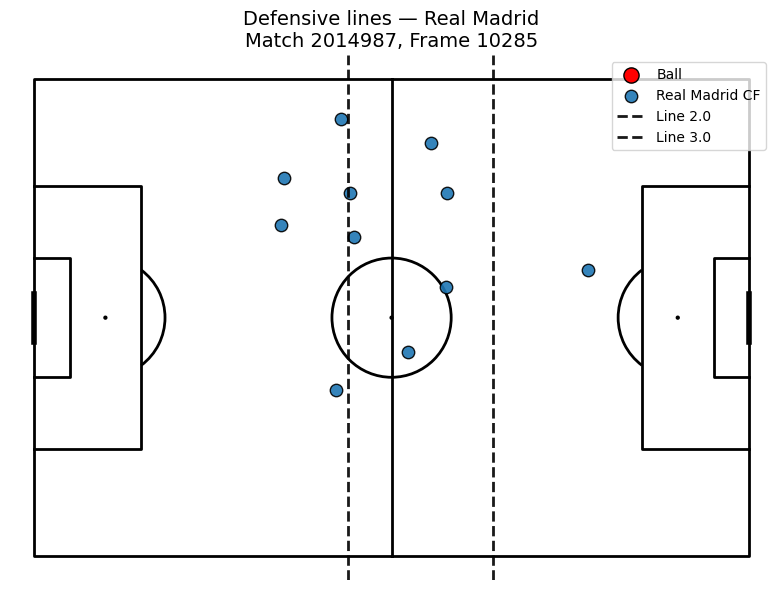

In [50]:

pitch = Pitch(pitch_type="statsbomb", pitch_length=105, pitch_width=68, line_color="black")
fig, ax = pitch.draw(figsize=(9,6))

# Ball
ball = frame_example[frame_example["is_ball"]]
ax.scatter(ball["x_rescaled"], ball["y_rescaled"], c="red", s=120, edgecolors="k", label="Ball")

# Players
for team, grp in frame_example.groupby("player_team_name"):
    ax.scatter(grp["x_rescaled"], grp["y_rescaled"], s=80, alpha=0.9, edgecolors="k", label=team)
    if team == TARGET_TEAM:
        for _, row in grp.iterrows():
            if not pd.isna(row.get("def_line_id")):
                ax.text(row["x_rescaled"]+0.5, row["y_rescaled"], int(row["def_line_id"]),
                        fontsize=8, color="white", ha="center", va="center")

# Draw vertical dashed lines for each line in this frame
for line_id, x_mean in line_means.items():
    ax.axvline(x_mean, linestyle="--", linewidth=2, color="black", alpha=0.9, label=f"Line {line_id}")

ax.set_title(f"Defensive lines — {TARGET_TEAM}\nMatch 2014987, Frame 10285", fontsize=14)

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
bylabel = dict(zip(labels, handles))
ax.legend(bylabel.values(), bylabel.keys(), loc="upper right")

plt.show()


# 📊 Season-Wide Defensive Line Stats

Step 1. Compute line depth per match/opponent

We take the mean x_rescaled of each line, grouped by match_id, opponent, and def_line_id.

In [51]:
# Add opponent column
rm_def_rows_labeled["opponent"] = np.where(
    rm_def_rows_labeled["team_shortname"] == rm_def_rows_labeled["player_team_shortname"],
    rm_def_rows_labeled["attacking_side"],  # fallback if needed
    rm_def_rows_labeled["team_shortname"]
)

# Defensive line stats per match & opponent
line_stats = (
    rm_def_rows_labeled
    .groupby(["match_id", "opponent", "def_line_id"])
    ["x_rescaled"]
    .mean()
    .reset_index()
    .rename(columns={"x_rescaled": "avg_depth"})
)

# Step 2. Pivot for clarity

# We want 1 row per match/opponent, with 3 columns = line depths.

line_stats_pivot = (
    line_stats
    .pivot_table(index=["match_id", "opponent"], 
                 columns="def_line_id", 
                 values="avg_depth")
    .reset_index()
    .rename(columns={1: "back_line_depth", 2: "midfield_line_depth", 3: "high_line_depth"})
)

print(line_stats_pivot.head())



def_line_id  match_id       opponent  back_line_depth  midfield_line_depth  high_line_depth
0             2014987     Celta Vigo        22.762384            51.615727        81.881267
1             2016604   FC Barcelona        22.497864            52.660492        83.055121
2             2017232   RCD Mallorca        23.039074            51.442931        80.992892
3             2017683     Sevilla FC        23.049619            52.053404        81.200209
4             2018396  Real Sociedad        24.052683            52.627290        81.739196


Step 3. Aggregate season-wide summary

You can now look at:

overall averages (season mean),

per opponent (tactical trends),

per match (game-to-game changes).

In [52]:
# Season-wide average defensive line depths
season_avg = line_stats_pivot[["back_line_depth", "midfield_line_depth", "high_line_depth"]].mean()
print("Season-wide average line depths (m from own goal):")
print(season_avg)

# Average by opponent
opponent_avg = (
    line_stats_pivot
    .groupby("opponent")[["back_line_depth", "midfield_line_depth", "high_line_depth"]]
    .mean()
    .sort_values("back_line_depth")
)
opponent_avg.head()


Season-wide average line depths (m from own goal):
def_line_id
back_line_depth        23.080325
midfield_line_depth    52.079969
high_line_depth        81.773737
dtype: float64


def_line_id,back_line_depth,midfield_line_depth,high_line_depth
opponent,,,
FC Barcelona,22.497864,52.660492,83.055121
Celta Vigo,22.762384,51.615727,81.881267
RCD Mallorca,23.039074,51.442931,80.992892
Sevilla FC,23.049619,52.053404,81.200209
Real Sociedad,24.052683,52.627290,81.739196


Step 4. Visualization (example: boxplots across matches)

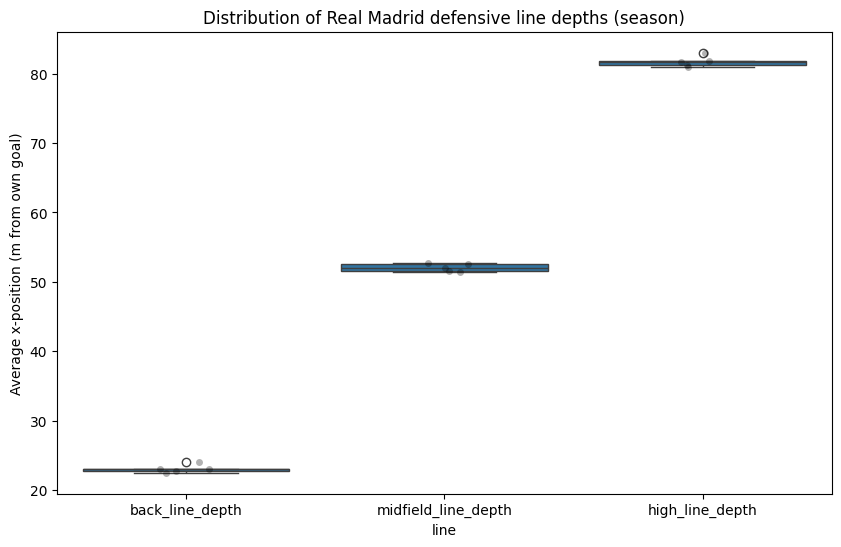

In [56]:

# Melt for plotting
melted = line_stats_pivot.melt(
    id_vars=["match_id", "opponent"], 
    value_vars=["back_line_depth", "midfield_line_depth", "high_line_depth"],
    var_name="line", value_name="depth"
)

plt.figure(figsize=(10,6))
# Plots the distribution of defensive line depths, showing the median, quartiles and outliers
sns.boxplot(data=melted, x="line", y="depth")
# Plots individual points 
sns.stripplot(data=melted, x="line", y="depth", color="black", alpha=0.3)
plt.title("Distribution of Real Madrid defensive line depths (season)")
plt.ylabel("Average x-position (m from own goal)")
plt.show()


# 📏 Adding Compactness Metrics

Step 1. Compute compactness at match level

We already have line_stats_pivot with 3 line depths per match.
Now we add distances between the lines.

In [57]:
line_stats_pivot["back_to_midfield"] = (
    line_stats_pivot["midfield_line_depth"] - line_stats_pivot["back_line_depth"]
)

line_stats_pivot["back_to_high"] = (
    line_stats_pivot["high_line_depth"] - line_stats_pivot["back_line_depth"]
)

line_stats_pivot["midfield_to_high"] = (
    line_stats_pivot["high_line_depth"] - line_stats_pivot["midfield_line_depth"]
)


Step 2. Season-wide averages

In [58]:
compactness_avg = line_stats_pivot[["back_to_midfield", "back_to_high", "midfield_to_high"]].mean()
print("Season-wide compactness (average distance between lines, meters):")
print(compactness_avg)


Season-wide compactness (average distance between lines, meters):
def_line_id
back_to_midfield    28.999644
back_to_high        58.693412
midfield_to_high    29.693768
dtype: float64


Step 3. Opponent-level compactness

In [59]:
opponent_compactness = (
    line_stats_pivot
    .groupby("opponent")[["back_to_midfield", "back_to_high", "midfield_to_high"]]
    .mean()
    .sort_values("back_to_midfield")
)

print(opponent_compactness.head())


def_line_id    back_to_midfield  back_to_high  midfield_to_high
opponent                                                       
RCD Mallorca          28.403857     57.953818         29.549961
Real Sociedad         28.574606     57.686512         29.111906
Celta Vigo            28.853343     59.118884         30.265541
Sevilla FC            29.003784     58.150589         29.146805
FC Barcelona          30.162628     60.557257         30.394629


Step 4. Visualization
Boxplot of compactness distributions

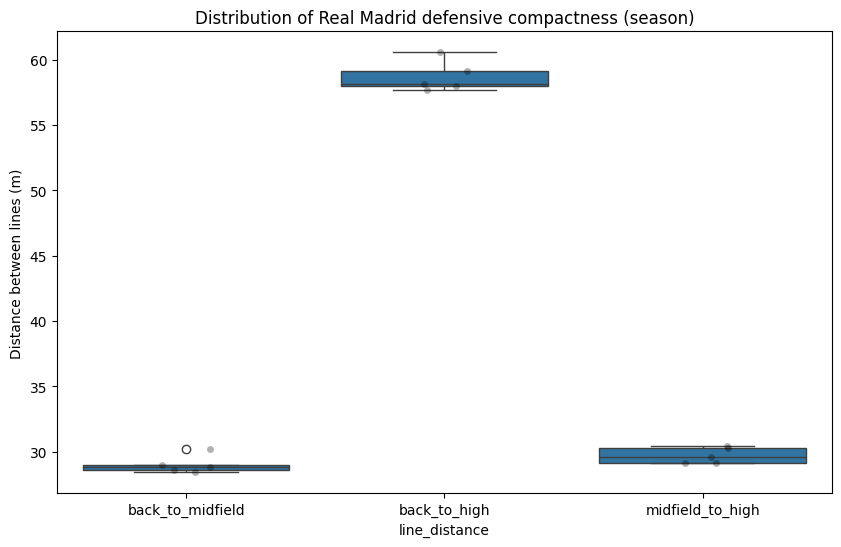

In [61]:
melted_compactness = line_stats_pivot.melt(
    id_vars=["match_id", "opponent"], 
    value_vars=["back_to_midfield", "back_to_high", "midfield_to_high"],
    var_name="line_distance", value_name="meters"
)

plt.figure(figsize=(10,6))
sns.boxplot(data=melted_compactness, x="line_distance", y="meters")
sns.stripplot(data=melted_compactness, x="line_distance", y="meters", color="black", alpha=0.3)
plt.title("Distribution of Real Madrid defensive compactness (season)")
plt.ylabel("Distance between lines (m)")
plt.show()


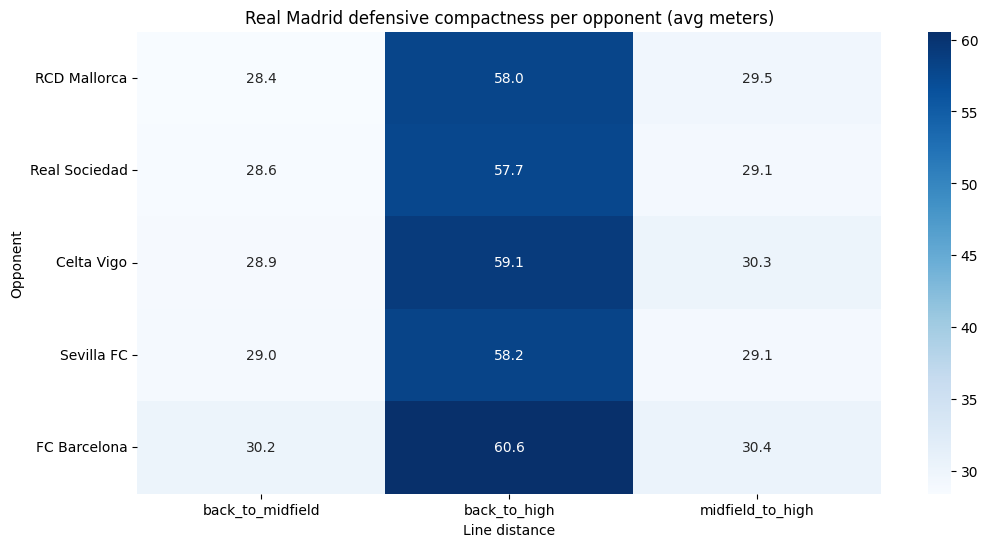

In [62]:
# Average defensive shape per opponent
plt.figure(figsize=(12,6))
sns.heatmap(opponent_compactness, annot=True, fmt=".1f", cmap="Blues")
plt.title("Real Madrid defensive compactness per opponent (avg meters)")
plt.ylabel("Opponent")
plt.xlabel("Line distance")
plt.show()


✅ With this, you can now analyze:

Depth of each defensive line across season.

Compactness between lines (back–midfield, back–high, midfield–high).

Opponent-specific adjustments (e.g., deeper + tighter vs stronger teams, higher + stretched vs weaker ones).